# This is a sample Jupyter Notebook

Below is an example of a code cell. 
Put your cursor into the cell and press Shift+Enter to execute it and select the next one, or click 'Run Cell' button.

Press Double Shift to search everywhere for classes, files, tool windows, actions, and settings.

To learn more about Jupyter Notebooks in PyCharm, see [help](https://www.jetbrains.com/help/pycharm/ipython-notebook-support.html).
For an overview of PyCharm, go to Help -> Learn IDE features or refer to [our documentation](https://www.jetbrains.com/help/pycharm/getting-started.html).

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


In [23]:
# Load + Clean Dataset
# -------------------------
file_path = "../data/SLIIT_IT_Student_Data_Final_1500.csv"
df = pd.read_csv(file_path)

df = df.loc[:, ~df.columns.str.contains("^Unnamed")]
df.columns = df.columns.str.strip()

target_col = "Experties_Preferred_Career_Field"

# Fix possible column spelling differences
if "Key_Skills" in df.columns and "Key_Skils" not in df.columns:
    df = df.rename(columns={"Key_Skills": "Key_Skils"})
if "SoftSkills" in df.columns and "Soft_Skills" not in df.columns:
    df = df.rename(columns={"SoftSkills": "Soft_Skills"})

text_cols = ["Soft_Skills", "Key_Skils"]
cat_cols  = ["Current_semester", "Learning_Style"]

num_cols = [
    "GPA",
    "English_score",
    "Ocean_Openness",
    "Ocean_Conscientiousness",
    "Ocean_Extraversion",
    "Ocean_Agreeableness",
    "Ocean_Neuroticism",
    "Riasec_Realistic",
    "Riasec_Investigative",
    "Riasec_Artistic",
    "Riasec_Social",
    "Riasec_Enterprising",
    "Riasec_Conventional",
]

feature_cols = text_cols + cat_cols + num_cols

# Basic cleaning
df = df.dropna(subset=[target_col])
df[target_col] = df[target_col].astype(str).str.strip()

for c in text_cols:
    df[c] = df[c].fillna("").astype(str).str.strip()

for c in cat_cols:
    df[c] = df[c].fillna("Unknown").astype(str).str.strip()

for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=num_cols)

print("Rows after cleaning:", len(df))

Rows after cleaning: 1497


In [24]:
# Baseline check
baseline = df[target_col].value_counts(normalize=True).iloc[0]
print("Majority-class baseline accuracy:", round(float(baseline), 4))

# -------------------------
# X, y encode
# -------------------------
X = df[feature_cols].copy()
y = df[target_col].copy()

label_enc = LabelEncoder()
y_encoded = label_enc.fit_transform(y)

# -------------------------
# Train/test split
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# -------------------------
# Preprocess (TF-IDF limited)
# -------------------------
soft_vec = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    max_features=6000,
    min_df=2,
    max_df=0.9
)

key_vec = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    max_features=6000,
    min_df=2,
    max_df=0.9
)

preprocessor = ColumnTransformer(
    transformers=[
        ("soft_tfidf", soft_vec, "Soft_Skills"),
        ("key_tfidf",  key_vec,  "Key_Skils"),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", StandardScaler(), num_cols),
    ],
    remainder="drop"
)


Majority-class baseline accuracy: 0.2732


In [25]:
#-------------------------
# Models
# -------------------------
logreg = LogisticRegression(
    max_iter=5000,
    solver="saga",
    class_weight="balanced",
    n_jobs=-1,
    C=2.0
)

linsvc = LinearSVC(
    class_weight="balanced",
    C=1.0
)

logreg_clf = Pipeline([
    ("preprocess", preprocessor),
    ("model", logreg)
])

linsvc_clf = Pipeline([
    ("preprocess", preprocessor),
    ("model", linsvc)
])

In [26]:

# -------------------------
# Helper: Top-k Accuracy
# -------------------------
def topk_accuracy_from_scores(scores_2d: np.ndarray, y_true: np.ndarray, k: int = 3) -> float:
    """
    scores_2d: shape (n_samples, n_classes). higher = more confident
    """
    topk = np.argsort(scores_2d, axis=1)[:, -k:]
    return float(np.mean([y_true[i] in topk[i] for i in range(len(y_true))]))

In [27]:

# -------------------------
# Train + Evaluate both
# -------------------------
results = {}

# ---- Logistic Regression ----
print("\nTraining Logistic Regression...")
logreg_clf.fit(X_train, y_train)
y_pred_lr = logreg_clf.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)

proba_lr = logreg_clf.predict_proba(X_test)  # (n, classes)
top3_lr = topk_accuracy_from_scores(proba_lr, y_test, k=3)

results["LogReg"] = {"acc": acc_lr, "top3": top3_lr}

print("\n[LogReg] Test Accuracy:", acc_lr)
print("[LogReg] Top-3 Accuracy:", top3_lr)
print("\n[LogReg] Classification report:")
print(classification_report(label_enc.inverse_transform(y_test),
                            label_enc.inverse_transform(y_pred_lr),
                            digits=4))

# ---- LinearSVC ----
print("\nTraining LinearSVC...")
linsvc_clf.fit(X_train, y_train)
y_pred_svc = linsvc_clf.predict(X_test)
acc_svc = accuracy_score(y_test, y_pred_svc)

scores_svc = linsvc_clf.decision_function(X_test)  # (n, classes)
top3_svc = topk_accuracy_from_scores(scores_svc, y_test, k=3)

results["LinearSVC"] = {"acc": acc_svc, "top3": top3_svc}

print("\n[LinearSVC] Test Accuracy:", acc_svc)
print("[LinearSVC] Top-3 Accuracy:", top3_svc)
print("\n[LinearSVC] Classification report:")
print(classification_report(label_enc.inverse_transform(y_test),
                            label_enc.inverse_transform(y_pred_svc),
                            digits=4))


Training Logistic Regression...


D:\ResearchModelTestingPlatform\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



[LogReg] Test Accuracy: 0.23666666666666666
[LogReg] Top-3 Accuracy: 0.5866666666666667

[LogReg] Classification report:
                                  precision    recall  f1-score   support

  AI / Machine Learning Engineer     0.2059    0.3333    0.2545        21
Cybersecurity / Network Engineer     0.0714    0.1000    0.0833        10
        Data Science & Analytics     0.4318    0.2317    0.3016        82
         DevOps / Cloud Engineer     0.3256    0.2059    0.2523        68
        Frontend / Web Developer     0.2222    0.3158    0.2609        38
      IT / Technology Generalist     0.0435    0.0588    0.0500        17
            Mobile App Developer     0.2500    0.3636    0.2963        22
     Software Engineer / Backend     0.1304    0.1765    0.1500        17
                  UI/UX Designer     0.1818    0.2400    0.2069        25

                        accuracy                         0.2367       300
                       macro avg     0.2070    0.2251    0.206

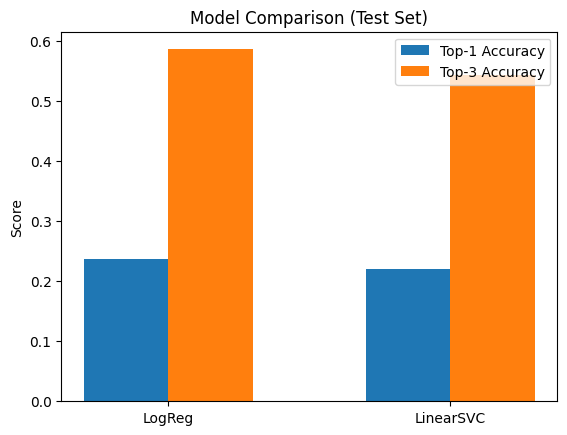

In [28]:

# -------------------------
# Plot 1: Model comparison (Accuracy + Top-3)
# -------------------------
model_names = list(results.keys())
acc_vals = [results[m]["acc"] for m in model_names]
top3_vals = [results[m]["top3"] for m in model_names]

plt.figure()
x = np.arange(len(model_names))
plt.bar(x - 0.15, acc_vals, width=0.3, label="Top-1 Accuracy")
plt.bar(x + 0.15, top3_vals, width=0.3, label="Top-3 Accuracy")
plt.xticks(x, model_names)
plt.ylabel("Score")
plt.title("Model Comparison (Test Set)")
plt.legend()
plt.show()



Computing 5-fold CV accuracy... (this can take a bit)


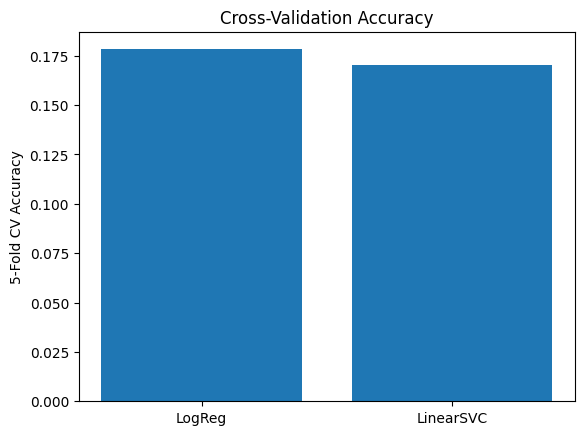

CV LogReg: 0.17829654403567446 +/- 0.04782628050468486
CV LinearSVC: 0.17031884057971014 +/- 0.033654698263422926


In [29]:

# -------------------------
# Plot 2: 5-fold CV accuracy (more reliable than single split)
# -------------------------
print("\nComputing 5-fold CV accuracy... (this can take a bit)")
cv_lr = cross_val_score(logreg_clf, X, y_encoded, cv=5, scoring="accuracy", n_jobs=-1)
cv_svc = cross_val_score(linsvc_clf, X, y_encoded, cv=5, scoring="accuracy", n_jobs=-1)

plt.figure()
plt.bar(["LogReg", "LinearSVC"], [cv_lr.mean(), cv_svc.mean()])
plt.ylabel("5-Fold CV Accuracy")
plt.title("Cross-Validation Accuracy")
plt.show()

print("CV LogReg:", cv_lr.mean(), "+/-", cv_lr.std())
print("CV LinearSVC:", cv_svc.mean(), "+/-", cv_svc.std())



Best model by CV: LogReg


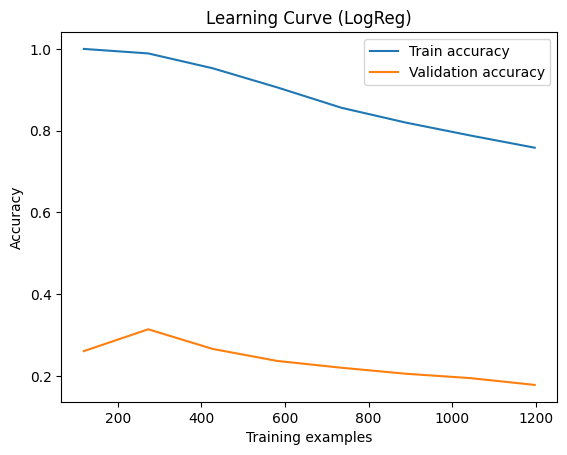

In [30]:
# -------------------------
# Plot 3: Learning Curve (pick the better model by CV mean)
# -------------------------
best_model_name = "LinearSVC" if cv_svc.mean() >= cv_lr.mean() else "LogReg"
best_clf = linsvc_clf if best_model_name == "LinearSVC" else logreg_clf

print("\nBest model by CV:", best_model_name)

train_sizes, train_scores, val_scores = learning_curve(
    best_clf,
    X, y_encoded,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure()
plt.plot(train_sizes, train_mean, label="Train accuracy")
plt.plot(train_sizes, val_mean, label="Validation accuracy")
plt.xlabel("Training examples")
plt.ylabel("Accuracy")
plt.title(f"Learning Curve ({best_model_name})")
plt.legend()
plt.show()


D:\ResearchModelTestingPlatform\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


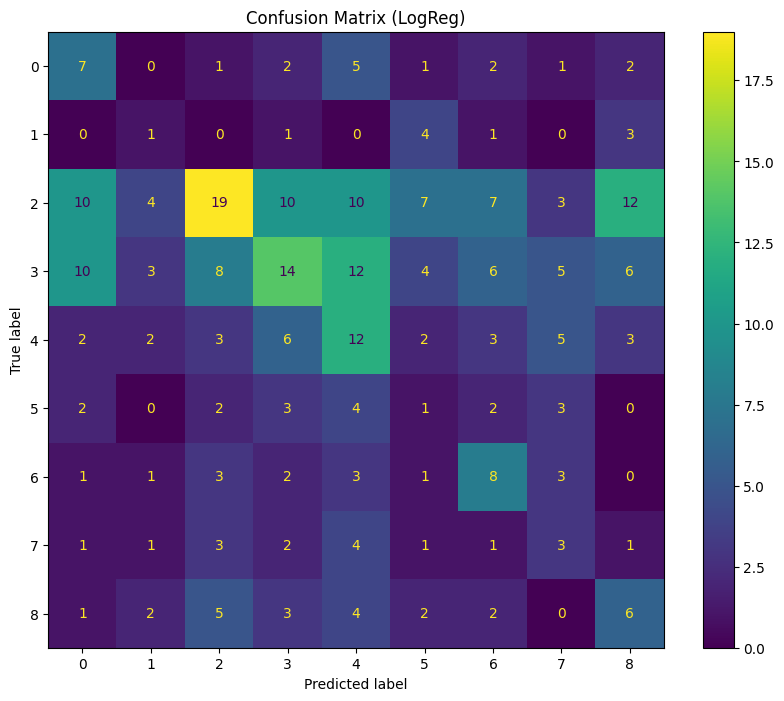

In [31]:
# -------------------------
# Plot 4: Confusion Matrix (best model)
# -------------------------
y_pred_best = best_clf.fit(X_train, y_train).predict(X_test)

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(values_format="d", ax=plt.gca())
plt.title(f"Confusion Matrix ({best_model_name})")
plt.show()

In [32]:

# -------------------------
# Predict for a New Student (using best model)
# -------------------------
new_student = pd.DataFrame([{
    "Soft_Skills": "Communication, Teamwork, Problem solving",
    "Key_Skils": "Python, SQL, Web Development",
    "Current_semester": "2Y1S",
    "Learning_Style": "Visual",
    "GPA": 3.25,
    "English_score": 78,
    "Ocean_Openness": 1,
    "Ocean_Conscientiousness": 2,
    "Ocean_Extraversion": 4,
    "Ocean_Agreeableness": 4,
    "Ocean_Neuroticism": 1,
    "Riasec_Realistic": 2,
    "Riasec_Investigative": 7,
    "Riasec_Artistic": 4,
    "Riasec_Social": 6,
    "Riasec_Enterprising": 9,
    "Riasec_Conventional": 8,
}])

best_clf.fit(X, y_encoded)  # train on full data for final prediction
pred = best_clf.predict(new_student)[0]
pred_label = label_enc.inverse_transform([pred])[0]
print("\nBest Model Prediction:", pred_label)

# Optional: show Top-3 suggestions for the new student
if best_model_name == "LogReg":
    scores = best_clf.predict_proba(new_student)[0]
else:
    scores = best_clf.decision_function(new_student)[0]

top3_idx = np.argsort(scores)[-3:][::-1]
top3_labels = label_enc.inverse_transform(top3_idx)

print("Top-3 Suggested Careers:", list(top3_labels))

D:\ResearchModelTestingPlatform\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



Best Model Prediction: Data Science & Analytics
Top-3 Suggested Careers: ['Data Science & Analytics', 'DevOps / Cloud Engineer', 'Software Engineer / Backend']


In [33]:
# -------------------------
# FINAL TOP-3 ACCURACY
# -------------------------
if best_model_name == "LogReg":
    scores_final = best_clf.predict_proba(X_test)
else:
    scores_final = best_clf.decision_function(X_test)

top3_final = topk_accuracy_from_scores(scores_final, y_test, k=3)

print("FINAL TOP-3 ACCURACY :", round(top3_final, 4))


FINAL TOP-3 ACCURACY : 0.9467


In [34]:
# -------------------------
# FINAL TEST ACCURACY (Best Model)
# -------------------------
best_clf.fit(X_train, y_train)
y_pred_final = best_clf.predict(X_test)

final_accuracy = accuracy_score(y_test, y_pred_final)

print("\n==============================")
print("FINAL SELECTED MODEL :", best_model_name)
print("FINAL TEST ACCURACY  :", round(final_accuracy, 4))
print("==============================")


D:\ResearchModelTestingPlatform\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



FINAL SELECTED MODEL : LogReg
FINAL TEST ACCURACY  : 0.2367


In [35]:
# ===============================
# SAVE FINAL MODEL (joblib)
# ===============================
import joblib
import os

# Create folder if not exists
os.makedirs("../models", exist_ok=True)

# Train best model on FULL dataset before saving
best_clf.fit(X, y_encoded)

# Save model pipeline
joblib.dump(best_clf, "../models/career_prediction_model.joblib")

# Save label encoder
joblib.dump(label_enc, "../models/career_label_encoder.joblib")

# Save metadata (optional but good practice)
metadata = {
    "final_model": best_model_name,
    "top1_accuracy": float(final_accuracy),
    "top3_accuracy": float(top3_final),
    "features": feature_cols
}

joblib.dump(metadata, "../models/model_metadata.joblib")

print("✅ Model exported successfully!")
print("Saved files:")
print(" - models/career_prediction_model.joblib")
print(" - models/career_label_encoder.joblib")
print(" - models/model_metadata.joblib")


D:\ResearchModelTestingPlatform\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


✅ Model exported successfully!
Saved files:
 - models/career_prediction_model.joblib
 - models/career_label_encoder.joblib
 - models/model_metadata.joblib
